In [2]:
import os
print(os.getcwd())
print(os.listdir())

E:\Kaggale Project\Task 4
['.ipynb_checkpoints', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'home-credit-default-risk.zip', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv', 'Untitled.ipynb']


In [3]:
import os
print(os.getcwd())
print(os.listdir())

E:\Kaggale Project\Task 4
['.ipynb_checkpoints', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'home-credit-default-risk.zip', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv', 'Untitled.ipynb']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, 
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
print("Imports done")

Imports done


In [5]:
df = pd.read_csv("application_train.csv")
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print(df.shape)
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True) * 100)

(307511, 122)
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
print(missing_df.head(20))
print(f"\nTotal columns with missing values: {len(missing_df)}")

                          Missing_Count  Missing_%
COMMONAREA_MEDI                  214865  69.872297
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_MODE            210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_AVG             210199  68.354953
FLOORSMIN_MODE                   208642  67.848630
FLOORSMIN_MEDI                   208642  67.848630
FLOORSMIN_AVG                    208642  67.848630
YEARS_BUILD_MODE                 204488  66.497784
YEARS_BUILD_MEDI                 204488  66.497784
YEARS_BUILD_AVG                  204488  66.497784
OWN_CAR_AGE                      202929  65.990810
LANDAREA_AVG                     182590  59.376738
LANDAREA_MEDI                  

In [8]:
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [9]:
missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >40% missing values")
df_clean = df.drop(columns=cols_to_drop)
print(df_clean.shape)

Dropping 49 columns with >40% missing values
(307511, 73)


In [10]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('TARGET')

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [11]:
print("Anomaly count:", (df_clean['DAYS_EMPLOYED'] == 365243).sum())

df_clean['DAYS_EMPLOYED_ANOM'] = (df_clean['DAYS_EMPLOYED'] == 365243).astype(int)
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace({365243: np.nan})
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].fillna(df_clean['DAYS_EMPLOYED'].median())

Anomaly count: 55374


In [12]:
df_model = df_clean.copy()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", len(cat_cols))

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(df_model.shape)

Categorical columns to encode: 12
(307511, 74)


In [13]:
X = df_model.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_model['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(246008, 72) (61503, 72)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC: 0.7435150371821685


In [15]:
pip install catboost

  Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 488.3 kB/s eta 0:03:25
   ---------------------------------------- 0.5/100.2 MB 488.3 kB/s eta 0:03:25
   ---------------------------------------- 0.5/100.2 MB 488.3 kB/s eta 0:03:25
   ---------------------------------------- 0.8/100.2 MB 474.1 kB/s eta 0:03:30
   ---------------------------------------- 0.8/100.2 MB 474.1 kB/s eta 0:03:30
   ---------------------------------

   ------------------------- ------------- 65.0/100.2 MB 292.3 kB/s eta 0:02:01
   ------------------------- ------------- 65.3/100.2 MB 292.3 kB/s eta 0:02:00
   ------------------------- ------------- 65.3/100.2 MB 292.3 kB/s eta 0:02:00
   ------------------------- ------------- 65.5/100.2 MB 304.2 kB/s eta 0:01:54
   ------------------------- ------------- 65.5/100.2 MB 304.2 kB/s eta 0:01:54
   ------------------------- ------------- 65.5/100.2 MB 304.2 kB/s eta 0:01:54
   ------------------------- ------------- 65.8/100.2 MB 307.2 kB/s eta 0:01:52
   ------------------------- ------------- 65.8/100.2 MB 307.2 kB/s eta 0:01:52
   ------------------------- ------------- 65.8/100.2 MB 307.2 kB/s eta 0:01:52
   ------------------------- ------------- 66.1/100.2 MB 309.5 kB/s eta 0:01:51
   ------------------------- ------------- 66.1/100.2 MB 309.5 kB/s eta 0:01:51
   ------------------------- ------------- 66.1/100.2 MB 309.5 kB/s eta 0:01:51
   ------------------------- -----------

In [16]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                                class_weights=[1, (len(y_train)-y_train.sum())/y_train.sum()],
                                random_state=42, verbose=50)
cat_model.fit(X_train, y_train)

y_pred_cb = cat_model.predict(X_test)
y_proba_cb = cat_model.predict_proba(X_test)[:,1]

print("CatBoost Results")
print(classification_report(y_test, y_pred_cb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_cb))

0:	learn: 0.6800855	total: 379ms	remaining: 1m 53s
50:	learn: 0.5949344	total: 8.75s	remaining: 42.7s
100:	learn: 0.5856320	total: 16.3s	remaining: 32.2s
150:	learn: 0.5776410	total: 22.7s	remaining: 22.4s
200:	learn: 0.5691745	total: 28.3s	remaining: 14s
250:	learn: 0.5611302	total: 34.5s	remaining: 6.73s
299:	learn: 0.5539027	total: 39.9s	remaining: 0us
CatBoost Results
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503

ROC-AUC: 0.7578747970734474


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC: 0.7435150371821685


In [19]:
COST_FN = 2500   
COST_FP = 500    

print(f"Cost of False Negative (missed default): ${COST_FN}")
print(f"Cost of False Positive (rejected good customer): ${COST_FP}")

Cost of False Negative (missed default): $2500
Cost of False Positive (rejected good customer): $500


In [20]:
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_proba_cb >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)

costs = np.array(costs)
optimal_threshold = thresholds[np.argmin(costs)]
min_cost = costs.min()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Total Business Cost: ${min_cost:,.0f}")
print(f"Cost at default threshold (0.5): ${costs[np.argmin(np.abs(thresholds-0.5))]:,.0f}")

Optimal Threshold: 0.69
Minimum Total Business Cost: $10,466,000
Cost at default threshold (0.5): $12,225,500


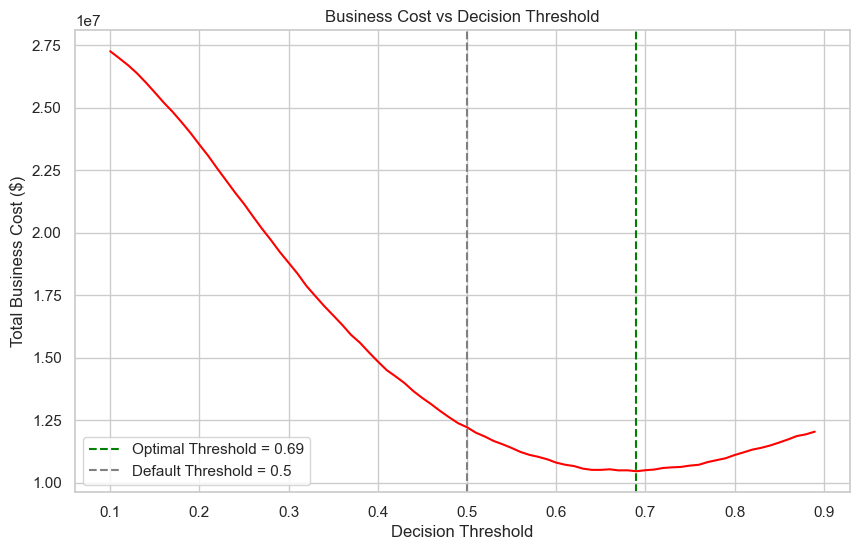

In [21]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, costs, color='red')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle='--', label='Default Threshold = 0.5')
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost ($)")
plt.title("Business Cost vs Decision Threshold")
plt.legend()
plt.show()

=== Results at Optimal Threshold (0.69) ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     56538
           1       0.26      0.35      0.30      4965

    accuracy                           0.87     61503
   macro avg       0.60      0.63      0.61     61503
weighted avg       0.89      0.87      0.88     61503



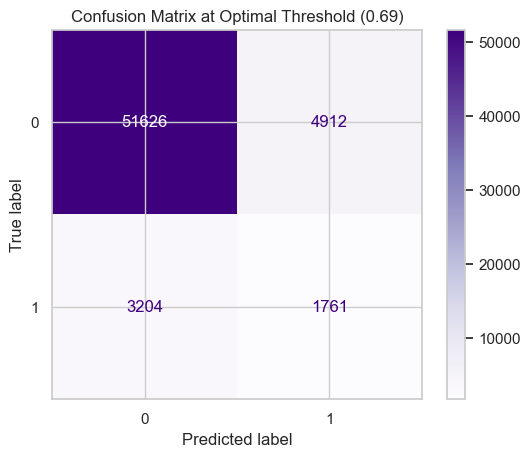

In [22]:
y_pred_optimal = (y_proba_cb >= optimal_threshold).astype(int)

print(f"=== Results at Optimal Threshold ({optimal_threshold:.2f}) ===")
print(classification_report(y_test, y_pred_optimal))

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
ConfusionMatrixDisplay(cm_optimal).plot(cmap='Purples')
plt.title(f"Confusion Matrix at Optimal Threshold ({optimal_threshold:.2f})")
plt.show()

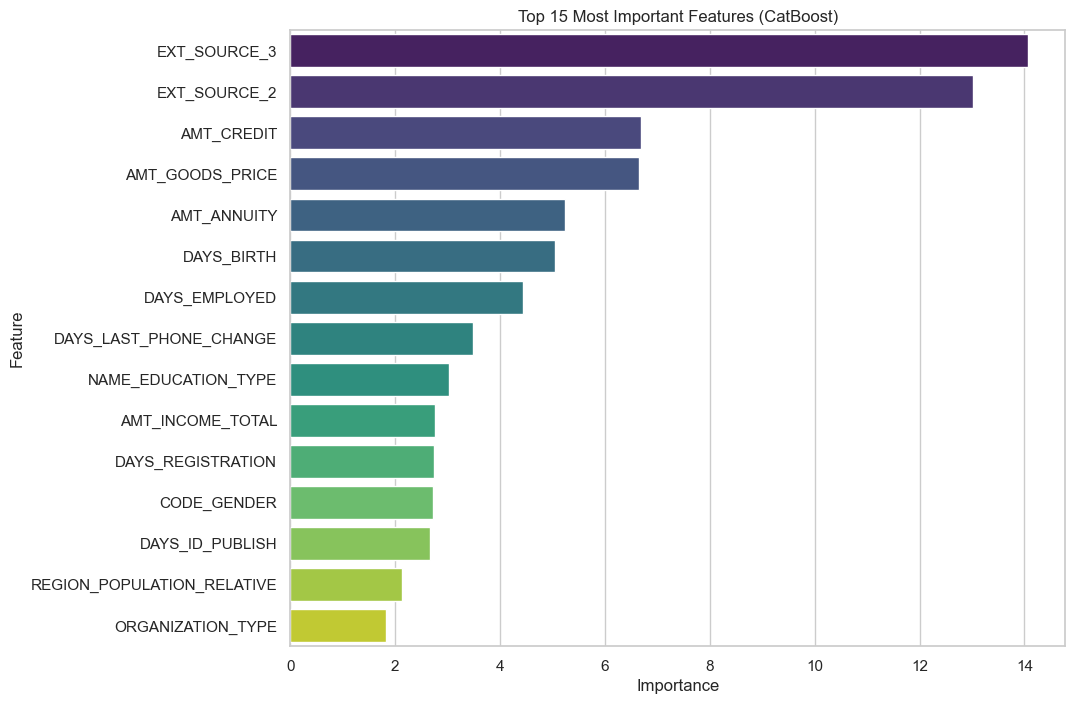

In [23]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title("Top 15 Most Important Features (CatBoost)")
plt.show()